# Session 1 - Common parameters

In [1]:
from __future__ import annotations
from dataclasses import dataclass, asdict
import numpy as np
from typing import Dict, Tuple, List

# -------------------------------
# SESSION 1. Common parameters
# -------------------------------

@dataclass
class Params:
    # --- Supersaturations (dimensionless) ---
    S_cm: float              # given (paper Eq.15 context)
    S_co: float              # case: 2.5, 3.0, 5.0
    # S_mo = S_co - S_cm (paper Eq.14 relation)
    # --- Interfacial terms (dimensionless = sigma * v^(2/3) / (k_B T)) ---
    gamma_mo: float
    gamma_cm: float
    # --- Kinetic scales (SM S10~S12) ---
    f0: float                # s^-1 (attachment on outer interface)
    g0: float                # s^-1 (growth inside metastable to crystal)
    Q: float                 # fraction to diagonal path (S12)
    alpha: float             # size exponent for f_{i,n} ∝ i^alpha
    beta: float              # size exponent for g_{i,n} ∝ n^beta
    eps: float               # size exponent for diagonal k_{i,i} ∝ i^eps
    # --- Lattice/Time ---
    M: int                   # triangular size bound: 1 <= n <= i <= M
    dt_x: float              # dimensionless step Δx with x = f0 * t
    x_max: float             # dimensionless final time
    # --- Monomer concentration in O phase (physical unit) ---
    C1: float                # m^-3
    # --- Derived (filled after init) ---
    S_mo: float = None       # computed S_co - S_cm
    w11: float = None        # w(1,1) = -S_co + (gamma_mo + gamma_cm)

    def finalize(self):
        self.S_mo = self.S_co - self.S_cm
        self.w11 = - self.S_co + (self.gamma_mo + self.gamma_cm)

def make_params_for_case(S_co: float, M: int = 240) -> Params:
    """Create Params for a given Sco case, with all agreed reference values."""
    p = Params(
        S_cm = 0.5,
        S_co = S_co,
        gamma_mo = 12.8,
        gamma_cm = 2.6,
        f0 = 1.0e5,     # s^-1 (SM S10)
        g0 = 2.0e7,     # s^-1 (SM S11)
        Q  = 0.5,       # (SM S12)
        alpha = 2.0/3.0,
        beta  = 2.0/3.0,
        eps   = 2.0/3.0,
        M = M,
        dt_x = 1.0e-4,    # dimensionless time step (x = f0 * t)
        x_max = 3.0,      # since t_max=30us -> x_max=f0*t_max=3.0
        C1 = 1.6e21 * np.exp(S_co)  # m^-3 (user-specified formula)
    )
    p.finalize()
    return p

# -------------------------------
# Utilities for triangular lattice
# -------------------------------

def build_triangle(M: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Return (I, N, mask) arrays of shape (M+1, M+1) for 1<=n<=i<=M (True in mask).
    Index (i,n) uses i as row, n as col.
    """
    I, N = np.indices((M+1, M+1))
    tri = (I >= 1) & (N >= 1) & (N <= I) & (I <= M)
    return I, N, tri

# Session 2 — Work of formation & ln C_eq

In [2]:
# -----------------------------------
# SESSION 2. Work of formation (Eq.15)
# -----------------------------------

def work_of_formation_grid(p: Params) -> np.ndarray:
    """
    w_{i,n} = -S_mo*i + gamma_mo*i^(2/3) - S_cm*n + gamma_cm*n^(2/3)
    Defined for 1<=n<=i<=M; elsewhere zeros (masked by caller).
    """
    M = p.M
    I, N, tri = build_triangle(M)
    # avoid 0^2/3; mask ensures i,n>=1
    w = np.zeros((M+1, M+1), dtype=float)
    ii = I[tri].astype(float)
    nn = N[tri].astype(float)
    w_vals = -p.S_mo * ii + p.gamma_mo * (ii ** (2.0/3.0)) \
             -p.S_cm * nn + p.gamma_cm * (nn ** (2.0/3.0))
    w[tri] = w_vals
    return w

def critical_sizes(p: Params) -> Tuple[float, float]:
    """
    Eq.(17): i*=(2γ_mo/(3 S_mo))^3,   n*=(2γ_cm/(3 S_cm))^3
    """
    i_star = (2.0 * p.gamma_mo / (3.0 * p.S_mo)) ** 3
    n_star = (2.0 * p.gamma_cm / (3.0 * p.S_cm)) ** 3
    return i_star, n_star

# Session 3 — Master equation

In [3]:
# ----------------------------------------------------------
# SESSION 3. Master equation (SM S10~S12, S17, S19~S24 etc.)
# ----------------------------------------------------------

def kinetic_scales(p: Params, w: np.ndarray) -> Dict[str, np.ndarray]:
    """
    Build constant-coefficient tables a,b,c,d,h for the triangular grid.
    SM-conformant definitions using only neighbor Δw exponentials.

    a_{i,n} = (f_{i-1,n}/f0) * exp(w_{i-1,n} - w_{i,n})
    b_{i,n} =  f_{i,n}/f0
    c_{i,n} = (g_{i,n-1}/f0) * exp(w_{i,n-1} - w_{i,n})
    d_{i,n} =  g_{i,n}/f0
    h_{i,n} = (k_{i,i-1}/f0) * exp(w_{i,i-1} - w_{i,i}),
              with k_{i,i-1} = Q * f0 * i^eps   (SM S12)

    Returns dict of arrays (shape M+1,M+1) with zeros outside the triangular mask.
    """
    M = p.M
    I, N, tri = build_triangle(M)

    a = np.zeros_like(w)
    b = np.zeros_like(w)
    c = np.zeros_like(w)
    d = np.zeros_like(w)
    h = np.zeros_like(w)

    # powers
    i_pow_a = (I.astype(float) ** p.alpha)
    n_pow_b = (N.astype(float) ** p.beta)
    i_pow_e = (I.astype(float) ** p.eps)

    # f_{i,n} = f0 * i^alpha ; g_{i,n} = g0 * n^beta
    f_in = p.f0 * i_pow_a
    g_in = p.g0 * n_pow_b
    # b_{i,n} = f_{i,n}/f0, d_{i,n} = g_{i,n}/f0
    b = f_in / p.f0
    d = g_in / p.g0 * (p.g0 / p.f0)   # simpler: d = g_in / p.f0
    d = g_in / p.f0

    # helper masks for neighbor existence inside triangle
    tri_im1 = np.zeros_like(tri); tri_im1[2:, :] = tri[1:-1, :]   # (i-1,n) exists when i>=2
    tri_nm1 = np.zeros_like(tri); tri_nm1[:, 2:] = tri[:, 1:-1]   # (i,n-1) exists when n>=2
    tri_diag = np.zeros_like(tri); tri_diag[2:, 2:] = tri[1:-1, 1:-1]  # (i-1, n-1)

    # a_{i,n}: uses (i-1,n)
    mask_a = tri & tri_im1
    dw_a = (w[:-1, :] - w[1:, :])  # w_{i-1,n} - w_{i,n}
    a[1:, :][mask_a[1:, :]] = (f_in[:-1, :][mask_a[1:, :]] / p.f0) * np.exp(dw_a[mask_a[1:, :]])

    # c_{i,n}: uses (i,n-1)
    mask_c = tri & tri_nm1
    dw_c = (w[:, :-1] - w[:, 1:])  # w_{i,n-1} - w_{i,n}
    c[:, 1:][mask_c[:, 1:]] = (g_in[:, :-1][mask_c[:, 1:]] / p.f0) * np.exp(dw_c[mask_c[:, 1:]])

    # h_{i,n}: uses (i,i-1) pair along diagonal n=i (and i-1,i-2)
    # generalize with (i, n) and (i-1, n-1) along diagonal direction:
    # k_{i,i-1} = Q * f0 * i^eps  (SM S12)
    k_diag = p.Q * p.f0 * i_pow_e  # shape (M+1, M+1)
    mask_h = tri & tri_diag
    dw_h = (w[:-1, :-1] - w[1:, 1:])  # w_{i-1,n-1} - w_{i,n}
    h[1:, 1:][mask_h[1:, 1:]] = (k_diag[:-1, :-1][mask_h[1:, 1:]] / p.f0) * np.exp(dw_h[mask_h[1:, 1:]])

    # zero everything outside tri (already zero)
    return dict(a=a, b=b, c=c, d=d, h=h, tri=tri)

def step_F_explicit(F: np.ndarray, coeff: Dict[str, np.ndarray], p: Params) -> np.ndarray:
    """
    One explicit Euler step for F using the coupled ODE (SM S17).
    Boundary conditions: zero flux across non-existent neighbors on the triangular edges.
    """
    a, b, c, d, h, tri = coeff["a"], coeff["b"], coeff["c"], coeff["d"], coeff["h"], coeff["tri"]
    M = p.M
    dt = p.dt_x

    F_new = F.copy()

    # Interior updates using neighbor shifts.
    # We'll compute terms with safe slicing respecting bounds and using the triangular mask.
    # Start with zero RHS
    RHS = np.zeros_like(F)

    # + a_{i,n} F_{i-1,n}
    RHS[1:, :] += a[1:, :] * F[:-1, :]
    # + b_{i-1,n} F_{i+1,n}
    RHS[:-1, :] += b[:-1, :] * F[1:, :]
    # + c_{i,n-1} F_{i,n-1}
    RHS[:, 1:] += c[:, 1:] * F[:, :-1]
    # + d_{i,n+1} F_{i,n+1}
    RHS[:, :-1] += d[:, :-1] * F[:, 1:]
    # + h_{i,n-1} F_{i-1,n-1}
    RHS[1:, 1:] += h[1:, 1:] * F[:-1, :-1]

    # - (a_{i+1,n}+b_{i,n}+c_{i,n}+d_{i,n}+h_{i,n}) F_{i,n}
    sink = np.zeros_like(F)
    sink[:-1, :] += a[1:, :]            # a_{i+1,n} at (i,n)
    sink += (b + c + d + h)
    RHS -= sink * F

    # Apply mask: update only inside triangular domain
    F_new[tri] = F[tri] + dt * RHS[tri]
    # keep outside-zero
    F_new[~tri] = 0.0

    # Minimal positivity guard (mathematically F can be tiny negative numerically)
    F_new[F_new < 0] = 0.0
    return F_new

# Session 4 — Nucleation rate

In [8]:
# --------------------------------------------
# SESSION 4. N(t), J(t) with log-gauge scaling (overflow-free, log-only)
# --------------------------------------------
import numpy as np
from typing import Dict

def equilibrium_C_hat_and_logS(p: Params, w: np.ndarray) -> tuple[np.ndarray, float]:
    """
    Exact gauge transform: C = S * C_hat
      L     = w11 - w
      Lmax  = max(L)
      C_hat = exp(L - Lmax)  ∈ (0,1]   (safe)
      logS  = log(C1) + Lmax           (scalar)
    """
    L = p.w11 - w
    Lmax = float(np.max(L))
    C_hat = np.exp(L - Lmax)           # <= 1 → overflow 없음
    logS  = np.log(p.C1) + Lmax        # ln S (스칼라)
    return C_hat, logS

def _logsumexp_pos(a: np.ndarray, mask: np.ndarray | None = None) -> float:
    """
    log(sum(a)) for a >= 0  (합이 0이면 -inf 반환). Overflow-free.
    """
    v = a[mask] if mask is not None else a.ravel()
    if v.size == 0:
        return float('-inf')
    m = np.max(v)
    if m <= 0.0:
        return float('-inf')           # sum == 0
    return np.log(np.sum(v / m)) + np.log(m)

def logN_from_F(F: np.ndarray, C_hat: np.ndarray, tri_mask: np.ndarray, logS: float) -> float:
    """
    ln N(t) = ln S + ln sum_{triangle} (F * C_hat).
    """
    ln_sum_hat = _logsumexp_pos(F * C_hat, tri_mask)
    return (logS + ln_sum_hat) if np.isfinite(ln_sum_hat) else float('-inf')

# --------- Fluxes in hat-gauge (physical flux / S) ---------

def flux_fields_hat(F: np.ndarray, C_hat: np.ndarray, p: Params) -> Dict[str, np.ndarray]:
    """
    I_hat = f_in * C_hat * (F - F_{i+1,n})
    G_hat = g_in * C_hat * (F - F_{i,  n+1})
    K_hat = k_in * C_hat * (F - F_{i+1,n+1})
    (hat: 물리 플럭스를 S로 나눈 값)
    """
    M = p.M
    Iidx, Nidx, tri = build_triangle(M)

    f_in = p.f0 * (Iidx.astype(float) ** p.alpha)
    g_in = p.g0 * (Nidx.astype(float) ** p.beta)
    k_in = p.Q  * p.f0 * (Iidx.astype(float) ** p.eps)

    I_hat = np.zeros_like(F); G_hat = np.zeros_like(F); K_hat = np.zeros_like(F)

    mI = tri.copy(); mI[:-1, :] &= tri[1:, :]
    I_hat[:-1, :][mI[:-1, :]] = (f_in[:-1, :][mI[:-1, :]] * C_hat[:-1, :][mI[:-1, :]]
                                 * (F[:-1, :][mI[:-1, :]] - F[1:, :][mI[:-1, :]]))

    mG = tri.copy(); mG[:, :-1] &= tri[:, 1:]
    G_hat[:, :-1][mG[:, :-1]] = (g_in[:, :-1][mG[:, :-1]] * C_hat[:, :-1][mG[:, :-1]]
                                 * (F[:, :-1][mG[:, :-1]] - F[:, 1:][mG[:, :-1]]))

    mK = tri.copy(); mK[:-1, :-1] &= tri[1:, 1:]
    K_hat[:-1, :-1][mK[:-1, :-1]] = (k_in[:-1, :-1][mK[:-1, :-1]] * C_hat[:-1, :-1][mK[:-1, :-1]]
                                     * (F[:-1, :-1][mK[:-1, :-1]] - F[1:, 1:][mK[:-1, :-1]]))

    return dict(I_hat=I_hat, G_hat=G_hat, K_hat=K_hat, tri=tri)

def logJ_from_flux_hat(flux_hat: Dict[str, np.ndarray], logS: float, p: Params) -> Dict[str, float]:
    """
    ln J_type = ln S + ln(sum of positive hat-fluxes over the boundary set).
    """
    tri = flux_hat["tri"]
    I_hat = np.maximum(flux_hat["I_hat"], 0.0)
    G_hat = np.maximum(flux_hat["G_hat"], 0.0)
    K_hat = np.maximum(flux_hat["K_hat"], 0.0)

    # crystallization line n=i → use G_hat[i, i-1]
    M = p.M
    g_line = np.asarray([G_hat[i, i-1] for i in range(2, M+1)], dtype=float) if M >= 2 else np.empty(0)

    lnJ_cr_hat = _logsumexp_pos(g_line)
    lnJ_co_hat = _logsumexp_pos(I_hat, tri)
    lnJ_dg_hat = _logsumexp_pos(K_hat, tri)
    lnJ_tot_hat = np.logaddexp(lnJ_cr_hat, np.logaddexp(lnJ_co_hat, lnJ_dg_hat))

    # add ln S
    lnJ_cr  = lnJ_cr_hat  + logS if np.isfinite(lnJ_cr_hat)  else float('-inf')
    lnJ_co  = lnJ_co_hat  + logS if np.isfinite(lnJ_co_hat)  else float('-inf')
    lnJ_dg  = lnJ_dg_hat  + logS if np.isfinite(lnJ_dg_hat)  else float('-inf')
    lnJ_tot = lnJ_tot_hat + logS if np.isfinite(lnJ_tot_hat) else float('-inf')

    return dict(lnJ_tot=lnJ_tot, lnJ_cr=lnJ_cr, lnJ_co=lnJ_co, lnJ_dg=lnJ_dg)


# Session 5 — Calculation & Plot helpers

In [9]:
# ---------------------------------------------------
# SESSION 5. Full simulation pipeline (log-only outputs)
# ---------------------------------------------------
from typing import Dict

def run_case(p: Params, record_every: int = 100) -> Dict[str, np.ndarray]:
    """
    2S kinetics with log-gauge (no linear reconstruction).
    Returns only log-series for N(t), J(t) + meta fields.
    """
    # Grid & fields
    M = p.M
    _, _, tri = build_triangle(M)
    w = work_of_formation_grid(p)                  # Session 2
    C_hat, logS = equilibrium_C_hat_and_logS(p, w) # Session 4
    coeff = kinetic_scales(p, w)                   # Session 3
    coeff["tri"] = tri

    # Initial condition (SM S18): F_{1,1}=1
    F = np.zeros_like(w); F[1, 1] = 1.0

    # Critical sizes
    i_star, n_star = critical_sizes(p)

    # Time setup
    n_steps = int(np.ceil(p.x_max / p.dt_x))
    # dt_phys = p.dt_x / p.f0   # (dN/dt 수치미분은 로그 체계에서 사용 안함)

    # Histories (log only)
    x_hist, t_hist = [], []
    N_log_hist, N_log10_hist = [], []
    J_tot_log_hist, J_cr_log_hist, J_co_log_hist, J_dg_log_hist = [], [], [], []

    for step in range(n_steps + 1):
        x = step * p.dt_x
        t = x / p.f0

        if (step % record_every == 0) or (step == n_steps):
            # ln N
            lnN = logN_from_F(F, C_hat, tri, logS)
            x_hist.append(x); t_hist.append(t)
            N_log_hist.append(lnN)
            N_log10_hist.append(lnN / np.log(10.0))

            # ln J_* (boundary sums)
            flux_hat = flux_fields_hat(F, C_hat, p)
            Lj = logJ_from_flux_hat(flux_hat, logS, p)
            J_tot_log_hist.append(Lj['lnJ_tot'])
            J_cr_log_hist.append(Lj['lnJ_cr'])
            J_co_log_hist.append(Lj['lnJ_co'])
            J_dg_log_hist.append(Lj['lnJ_dg'])

        if step == n_steps:
            break

        # One explicit Euler step for F (Session 3)
        F = step_F_explicit(F, coeff, p)

    # Pack (log-only)
    out = dict(
        t=np.array(t_hist), x=np.array(x_hist),
        N_log=np.array(N_log_hist), N_log10=np.array(N_log10_hist),
        J_tot_log=np.array(J_tot_log_hist),
        J_cryst_log=np.array(J_cr_log_hist),
        J_comp_log=np.array(J_co_log_hist),
        J_diag_log=np.array(J_dg_log_hist),
        # fields / meta
        F=F, C_hat=C_hat, w=w, tri=tri,
        i_star=i_star, n_star=n_star, params=asdict(p)
    )
    # 편의: base-10 버전도 제공
    out["J_tot_log10"]   = out["J_tot_log"]   / np.log(10.0)
    out["J_cryst_log10"] = out["J_cryst_log"] / np.log(10.0)
    out["J_comp_log10"]  = out["J_comp_log"]  / np.log(10.0)
    out["J_diag_log10"]  = out["J_diag_log"]  / np.log(10.0)
    return out


## Session 5A - 실행 예시

In [10]:
# -------------------------------
# SESSION 6. Plot helpers (log10 series, μs time)
# -------------------------------
import matplotlib.pyplot as plt

def plot_work_of_formation(ax, w: np.ndarray, tri: np.ndarray,
                           p: Params, i_star: float, n_star: float):
    M = p.M
    W = np.ma.array(w.T, mask=~tri.T)   # X=i, Y=n 로 보이게 전치
    im = ax.imshow(W, origin='lower', extent=[1, M, 1, M], aspect='equal', interpolation='nearest')
    ax.plot([1, M], [1, M], 'w--', lw=1, alpha=0.8)   # n=i 경계
    ax.set_xlim(1, M); ax.set_ylim(1, M)
    ax.set_xlabel("i"); ax.set_ylabel("n")
    ax.set_title(f"Work of formation w(i,n) | Sco={p.S_co}")
    ax.plot(i_star, n_star, 'kx', ms=8, mew=2, label='(i*, n*)'); ax.legend(loc='best')
    plt.colorbar(im, ax=ax, fraction=0.046)

def plot_concentration_log(ax, t: np.ndarray, N_log10: np.ndarray, p: Params):
    ax.plot(t*1e6, N_log10)
    ax.set_title(f"Concentration N(t) | Sco={p.S_co}")
    ax.set_xlabel("t (μs)"); ax.set_ylabel("log10 N")

def plot_nucleation_rate_log(ax, t: np.ndarray, J_log10: np.ndarray, p: Params, label="J_tot"):
    ax.plot(t*1e6, J_log10, label=label)
    ax.set_title(f"Nucleation rate | Sco={p.S_co}")
    ax.set_xlabel("t (μs)"); ax.set_ylabel("log10 J")
    ax.legend()


In [11]:
import numpy as np
np.seterr(all='raise')  # overflow/underflow/invalid를 예외로 즉시 보고

# 가장 빡센 케이스 (Sco=5.0) 단일 실행
p = make_params_for_case(5.0, M=240)
out = run_case(p, record_every=200)  # 기록 간격은 상황에 맞게

print("max log10 N :", np.nanmax(out['N_log10']))
print("max log10 J :", np.nanmax(out['J_tot_log10']))

# 플롯 (로그스케일)
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(17, 4))
plot_work_of_formation(axs[0], out['w'], out['tri'], p, out['i_star'], out['n_star'])
plot_concentration_log(axs[1], out['t'], out['N_log10'], p)
plot_nucleation_rate_log(axs[2], out['t'], out['J_tot_log10'], p, label="J_tot (boundary)")
plt.tight_layout(); plt.show()


FloatingPointError: underflow encountered in multiply

## Session 5B - 저장된 결과 불러와서 plot하기

C:\Users\USER\AppData\Local\Temp\ipykernel_7920\2696616603.py:90: RuntimeWarning: overflow encountered in add
  RHS[:, :-1] += d[:, :-1] * F[:, 1:]
C:\Users\USER\AppData\Local\Temp\ipykernel_7920\2696616603.py:98: RuntimeWarning: overflow encountered in multiply
  RHS -= sink * F
C:\Users\USER\AppData\Local\Temp\ipykernel_7920\2696616603.py:101: RuntimeWarning: invalid value encountered in add
  F_new[tri] = F[tri] + dt * RHS[tri]
C:\Users\USER\AppData\Local\Temp\ipykernel_7920\2696616603.py:88: RuntimeWarning: invalid value encountered in multiply
  RHS[:, 1:] += c[:, 1:] * F[:, :-1]
C:\Users\USER\AppData\Local\Temp\ipykernel_7920\956242795.py:107: RuntimeWarning: invalid value encountered in logaddexp
  lnJ_tot_hat = np.logaddexp(lnJ_cr_hat, np.logaddexp(lnJ_co_hat, lnJ_dg_hat))
C:\Users\USER\AppData\Local\Temp\ipykernel_7920\2696616603.py:90: RuntimeWarning: invalid value encountered in multiply
  RHS[:, :-1] += d[:, :-1] * F[:, 1:]
C:\Users\USER\AppData\Local\Temp\ipykernel_7920\26

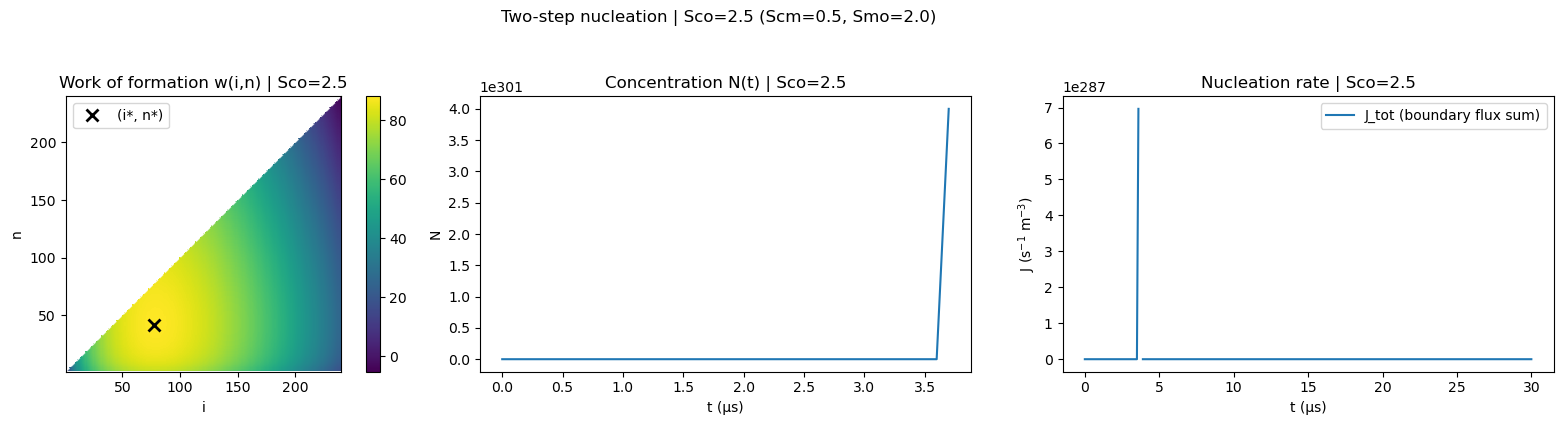

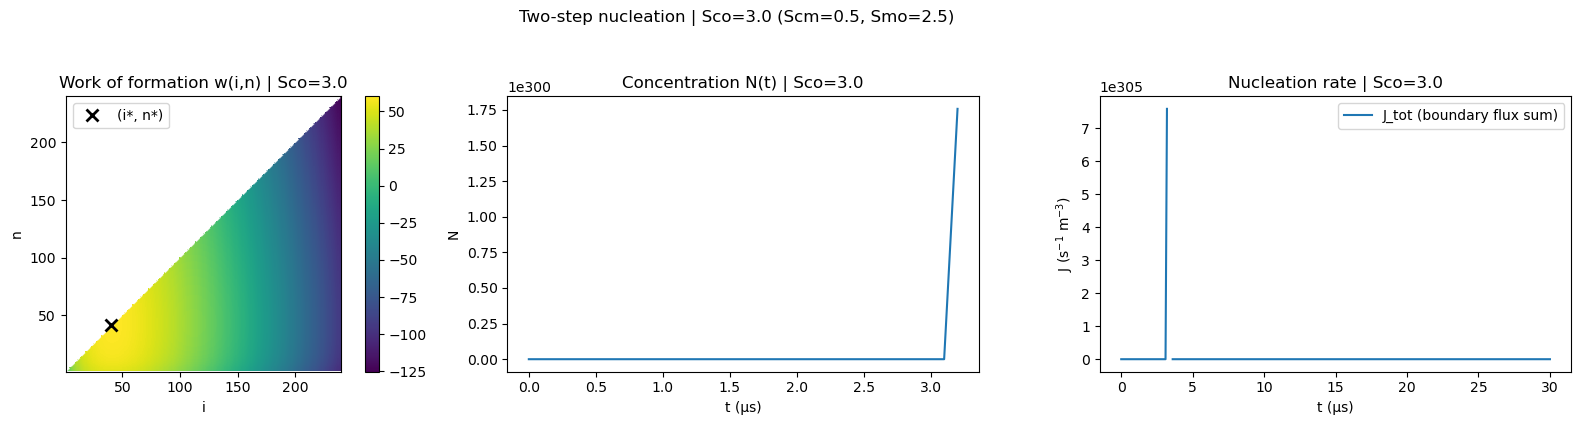

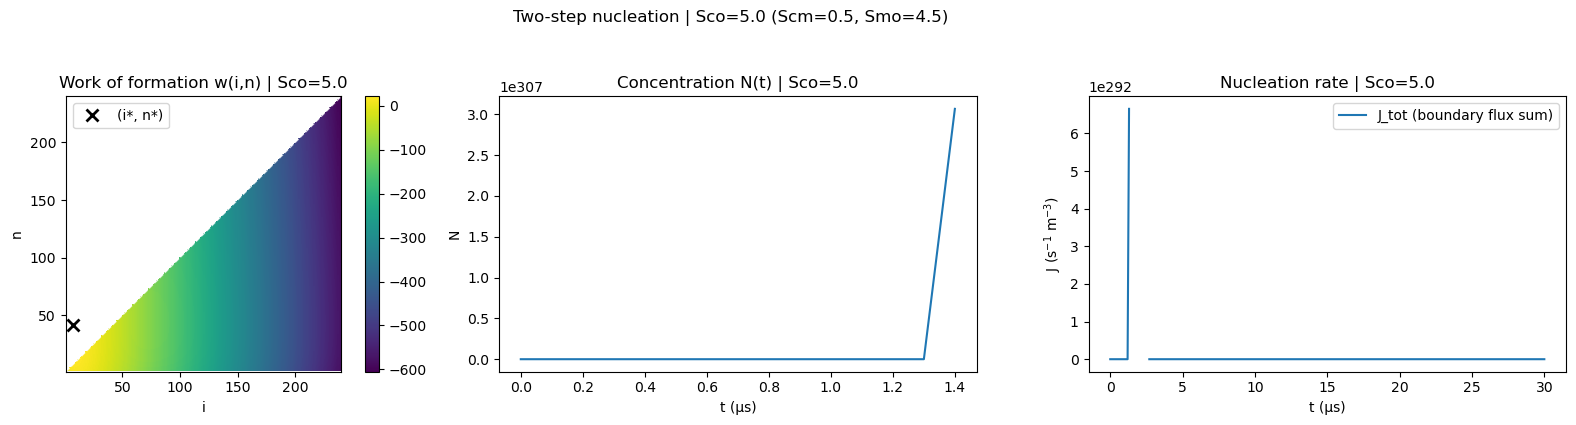

In [7]:
cases = [2.5, 3.0, 5.0]
outs = []
for Sco in cases:
    p = make_params_for_case(Sco, M=240)
    out = run_case(p, record_every=100)
    outs.append((p, out))

for (p, out) in outs:
    fig, axs = plt.subplots(1, 3, figsize=(17, 4))

    # (1) Work of formation
    plot_work_of_formation(axs[0], out['w'], out['tri'], p, out['i_star'], out['n_star'])

    # (2) Concentration N(t)
    plot_concentration(axs[1], out['t'], out['N'], p)

    # (3) Nucleation rate (boundary-flux 기반)
    plot_nucleation_rate(axs[2], out['t'], out['J_tot'], p)

    plt.suptitle(f"Two-step nucleation | Sco={p.S_co} (Scm=0.5, Smo={p.S_mo})", y=1.05)
    plt.tight_layout()
    plt.show()
